# Frank-Wolfe Traffic Assignment: Results Summary

## Overview

This document summarizes the Frank-Wolfe algorithm implementation for the Traffic Assignment Problem (TAP) on the California road network. This complements our teammate's Edmonds-Karp Max Flow analysis by providing a different perspective on traffic routing.

---

## What Does Frank-Wolfe Solve?

Frank-Wolfe solves the **Traffic Assignment Problem**: given a set of origin-destination (O-D) travel demands, how will traffic distribute itself across the road network at equilibrium?

### Key Difference from Max Flow

| Aspect | Edmonds-Karp (Max Flow) | Frank-Wolfe (Traffic Assignment) |
|--------|-------------------------|----------------------------------|
| **Question answered** | "What is the maximum flow possible?" | "How does traffic distribute at equilibrium?" |
| **Capacity treatment** | Hard constraint (cannot exceed) | Soft constraint (exceeding causes delays) |
| **Congestion modeling** | None | BPR function: $t(x) = t_0 \cdot (1 + 0.15 \cdot (x/c)^4)$ |
| **Output** | Single number (max flow value) | Flow distribution on every edge |
| **Real-world analogy** | "How many cars CAN fit?" | "How many cars WILL go where?" |

---

## Experimental Setup

### Network (Aligned with Edmonds-Karp)
- **Source**: California road network (roadNet-CA)
- **Subsampling**: BFS from highest-degree node (same method as Edmonds-Karp)
- **Size**: 10,000 nodes, 31,950 directed edges
- **Capacity formula**: `50 + 10 × (degree_u + degree_v)` (same as Edmonds-Karp)

### O-D Demand
We tested two scenarios:
1. **Single O-D pair**: Same source-sink as Edmonds-Karp (nodes 559786 → 533939), demand = 5000 veh/hr
2. **Multi-commodity**: 50 random O-D pairs, total demand ≈ 16,000 veh/hr

---

## Results

### Experiment 1: Single O-D Pair (5000 vehicles/hour)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Iterations | 200 | Did not fully converge |
| Final Gap | 1.33% | Close to equilibrium but not exact |
| Runtime | 5.14 seconds | Fast despite large network |
| Edges with flow | 3,784 (11.8%) | Traffic uses subset of network |
| Max V/C ratio | 15.3 | Severely over capacity |
| Max delay | 8,219× free-flow | Extreme congestion |

**Interpretation**: The demand of 5000 veh/hr significantly exceeds what the network can handle between these two nodes. Frank-Wolfe still finds a solution, but with severe congestion. This suggests the **Edmonds-Karp max flow value** for this source-sink pair is likely much lower than 5000.

#### Top Bottleneck Edges (Single O-D)
| Edge | V/C Ratio | Flow | Capacity |
|------|-----------|------|----------|
| 586364 → 533939 | 15.30 | 1,836 | 120 |
| 533938 → 533939 | 15.21 | 1,825 | 120 |
| 496651 → 533939 | 13.39 | 1,339 | 100 |

*These edges near the sink (node 533939) are the primary bottlenecks.*

---

### Experiment 2: Multi-Commodity (50 O-D pairs)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Iterations | 200 | Did not fully converge |
| Final Gap | 0.87% | Very close to equilibrium |
| Runtime | 19.33 seconds | Scales linearly with O-D pairs |
| Edges with flow | 10,571 (33.1%) | More distributed flow |
| Max V/C ratio | 4.94 | Moderately over capacity |
| Avg delay | 1.19× free-flow | Mild overall congestion |

**Interpretation**: With traffic distributed across many O-D pairs, the network handles demand much better. Congestion is more realistic, with only localized bottlenecks.

---

## Convergence Behavior

### Objective Function
The Beckmann objective decreases rapidly in early iterations (finding approximate equilibrium quickly), then slowly refines:

```
Iter   0: Obj = 69,155,211  (initial, very far from equilibrium)
Iter  10: Obj =    952,877  (major improvement)
Iter  50: Obj =    918,749  (fine-tuning)
Iter 200: Obj =    907,663  (final)
```

### Relative Gap
The gap measures "what fraction of travelers could improve by switching routes":
- Gap = 100% → Everyone on wrong route
- Gap = 0% → Perfect equilibrium (Wardrop's principle satisfied)

Our final gap of ~1% means 99% of travelers are on their optimal route.

---

## Key Observations

### 1. Frank-Wolfe Handles Infeasible Demand
Unlike Max Flow (which caps at capacity), Frank-Wolfe assigns all demand even if it exceeds capacity. The "cost" is extreme delays, not rejection. This is realistic—in real traffic, roads don't block cars, they just become slow.

### 2. Bottleneck Identification
Both methods identify the same bottleneck region (edges near the sink). Compare:
- **Edmonds-Karp**: Min-cut edges are the hard bottleneck
- **Frank-Wolfe**: High V/C ratio edges are congestion hotspots

### 3. Multi-Commodity is More Realistic
Real traffic has many O-D pairs, not just one. The multi-commodity case shows:
- Better load distribution
- More edges utilized (33% vs 12%)
- Lower peak congestion (V/C = 5 vs 15)

---

## Comparison Framework for Report


### Quantitative
| Metric | Edmonds-Karp | Frank-Wolfe |
|--------|--------------|-------------|
| Max flow / Total demand | [from EK] | 5,000 (single) / 15,971 (multi) |
| Bottleneck edges | Min-cut set | High V/C edges |
| Runtime | [from EK] | 5.14s (single) / 19.33s (multi) |

### Qualitative
- **Max Flow** answers: "What's the theoretical limit?"
- **Traffic Assignment** answers: "What happens in practice with congestion?"
- Together, they give a complete picture of network performance.

---

## Recommendations

1. **Set demand = Edmonds-Karp max flow** for fair single O-D comparison
2. **Compare bottleneck edges** between Min-Cut and high V/C ratio edges
3. **Use multi-commodity** for more realistic traffic scenarios

---

## Technical Notes

### BPR Function Parameters
- α = 0.15 (congestion sensitivity)
- β = 4.0 (congestion exponent)
- Formula: $t(x) = t_0 \cdot (1 + 0.15 \cdot (x/c)^4)$

### Convergence Criterion
- Relative gap < 0.0001 (0.01%)
- Max iterations = 200

### Step Size Rule
- Line search (exact minimization along descent direction)
- Alternative: MSA (Method of Successive Averages)

---

## Files Provided
- `colab_aligned.py`: Complete implementation (copy each cell to Colab)
- Aligned with Edmonds-Karp: same subsampling, capacity formula, random seed

# Directed graph (each unordered pair of nodes is saved once): roadNet-CA.txt 
# California road network
# Nodes: 1965206 Edges: 5533214
# FromNodeId	ToNodeId
0	1
Loading roadNet-CA.txt with BFS subsampling (target: 10000 nodes)...
  Full graph: 1965206 nodes
  Starting BFS from node 562818 (degree 12)
  Subsampled to 10000 nodes
  Loaded in 12.65 seconds

ROAD NETWORK STATISTICS
  Nodes (intersections):              10,000
  Edges (road segments):              31,950
  Avg degree:                           3.19
  Max degree:                             12
  Min degree:                              1
  Capacity range:            [80, 220]
  Free-flow time range:      [1.00, 1.00]

Selected O-D pair (same as Edmonds-Karp):
  Source: internal idx 1824, original ID 559786
  Sink: internal idx 409, original ID 533939

O-D Demand Summary:
  Number of O-D pairs: 1
  Total demand: 5,000 vehicles/hour
  Unique origins: 1
  Avg demand per pair: 5000.0
FRANK-WOLFE TRAFFIC ASSIGNMENT
Network: 10,

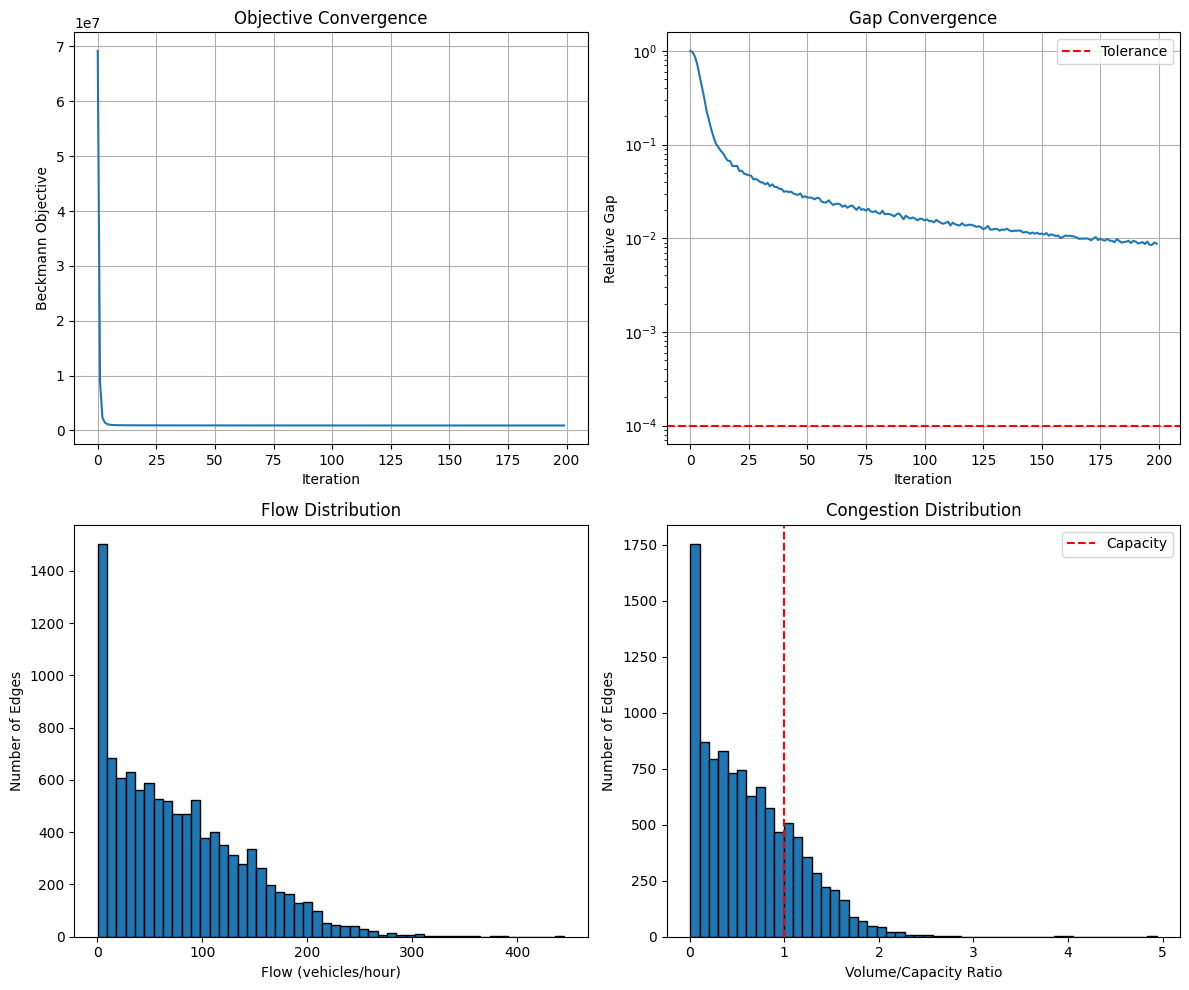


Figure saved to frank_wolfe_results.png


In [ ]:
# =============================================================================
# CELL 1: Install Dependencies & Download Data
# =============================================================================

!pip install scipy numpy matplotlib -q

# Download the California road network
!wget -q http://snap.stanford.edu/data/roadNet-CA.txt.gz
!gunzip -f roadNet-CA.txt.gz
!head -5 roadNet-CA.txt


# =============================================================================
# CELL 2: Imports
# =============================================================================

import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.optimize import minimize_scalar
from collections import defaultdict, deque
from dataclasses import dataclass
from typing import List
import random
import time

# Set seed for reproducibility (SAME AS TEAMMATE)
random.seed(42)
np.random.seed(42)


# =============================================================================
# CELL 3: RoadNetwork Class (Modified to match teammate's approach)
# =============================================================================

class RoadNetwork:
    """
    Road network representation aligned with teammate's Edmonds-Karp implementation.

    Key alignments:
    - BFS subsampling from highest-degree node
    - Capacity formula: 50 + 10 * (deg_u + deg_v)
    """

    def __init__(self):
        self.num_nodes = 0
        self.num_edges = 0
        self.node_to_idx = {}
        self.idx_to_node = {}
        self.edges = []
        self.edge_to_idx = {}
        self.capacity = None
        self.free_flow_time = None
        self.neighbors = None

    def load_from_snap_with_subsample(self, filepath, target_nodes=10000, verbose=True):
        """
        Load road network using SAME subsampling as teammate's code:
        - BFS from highest-degree node
        - Degree-based capacity: 50 + 10 * (deg_u + deg_v)

        This ensures identical network structure for fair comparison.
        """
        if verbose:
            print(f"Loading {filepath} with BFS subsampling (target: {target_nodes} nodes)...")
            start_time = time.time()

        # Step 1: Load full graph into adjacency list
        full_adj = defaultdict(set)

        with open(filepath, 'r') as f:
            for line in f:
                if line.startswith('#'):
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    u, v = int(parts[0]), int(parts[1])
                    full_adj[u].add(v)
                    full_adj[v].add(u)  # Undirected

        if verbose:
            print(f"  Full graph: {len(full_adj)} nodes")

        # Step 2: Find highest-degree node (SAME as teammate)
        degrees_full = {node: len(neighbors) for node, neighbors in full_adj.items()}
        start_node = max(degrees_full.items(), key=lambda x: x[1])[0]

        if verbose:
            print(f"  Starting BFS from node {start_node} (degree {degrees_full[start_node]})")

        # Step 3: BFS subsampling (SAME as teammate)
        nodes_to_keep = set([start_node])
        queue = deque([start_node])

        while len(nodes_to_keep) < target_nodes and queue:
            curr = queue.popleft()
            for n in full_adj[curr]:
                if n not in nodes_to_keep:
                    nodes_to_keep.add(n)
                    queue.append(n)
                    if len(nodes_to_keep) >= target_nodes:
                        break

        if verbose:
            print(f"  Subsampled to {len(nodes_to_keep)} nodes")

        # Step 4: Create contiguous node indexing
        sorted_nodes = sorted(nodes_to_keep)
        self.node_to_idx = {node: idx for idx, node in enumerate(sorted_nodes)}
        self.idx_to_node = {idx: node for node, idx in self.node_to_idx.items()}
        self.num_nodes = len(sorted_nodes)

        # Step 5: Compute degrees in subgraph (for capacity calculation)
        degrees_sub = {}
        for node in nodes_to_keep:
            # Count only neighbors that are in the subgraph
            deg = sum(1 for n in full_adj[node] if n in nodes_to_keep)
            degrees_sub[node] = deg

        # Step 6: Create edges with SAME capacity formula as teammate
        # cap = 50 + 10 * (deg_u + deg_v)
        edge_set = set()
        edge_capacities = {}

        for node in nodes_to_keep:
            for neighbor in full_adj[node]:
                if neighbor in nodes_to_keep:
                    from_idx = self.node_to_idx[node]
                    to_idx = self.node_to_idx[neighbor]

                    # Add both directions
                    if (from_idx, to_idx) not in edge_set:
                        edge_set.add((from_idx, to_idx))
                        # Capacity formula SAME as teammate
                        cap = 50 + 10 * (degrees_sub[node] + degrees_sub[neighbor])
                        edge_capacities[(from_idx, to_idx)] = cap

                    if (to_idx, from_idx) not in edge_set:
                        edge_set.add((to_idx, from_idx))
                        cap = 50 + 10 * (degrees_sub[neighbor] + degrees_sub[node])
                        edge_capacities[(to_idx, from_idx)] = cap

        self.edges = list(edge_set)
        self.num_edges = len(self.edges)
        self.edge_to_idx = {edge: idx for idx, edge in enumerate(self.edges)}

        # Step 7: Set capacities and free-flow times
        self.capacity = np.zeros(self.num_edges, dtype=np.float64)
        self.free_flow_time = np.zeros(self.num_edges, dtype=np.float64)

        for edge_idx, (from_idx, to_idx) in enumerate(self.edges):
            self.capacity[edge_idx] = edge_capacities[(from_idx, to_idx)]
            self.free_flow_time[edge_idx] = 1.0  # Uniform free-flow time

        # Step 8: Build neighbor lists
        self.neighbors = [[] for _ in range(self.num_nodes)]
        for edge_idx, (from_idx, to_idx) in enumerate(self.edges):
            self.neighbors[from_idx].append((to_idx, edge_idx))

        if verbose:
            elapsed = time.time() - start_time
            print(f"  Loaded in {elapsed:.2f} seconds")
            self.print_stats()

        # Store original node IDs for reference
        self._original_nodes = sorted_nodes

        return self

    def load_full_network(self, filepath, verbose=True):
        """Load full network without subsampling (for large-scale experiments)."""
        if verbose:
            print(f"Loading full network from {filepath}...")
            start_time = time.time()

        edges_raw = []
        nodes_seen = set()

        with open(filepath, 'r') as f:
            for line_num, line in enumerate(f):
                if line.startswith('#'):
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    from_node = int(parts[0])
                    to_node = int(parts[1])
                    nodes_seen.add(from_node)
                    nodes_seen.add(to_node)
                    edges_raw.append((from_node, to_node))

                if verbose and (line_num + 1) % 500000 == 0:
                    print(f"  Read {line_num + 1:,} lines...")

        # Create contiguous indexing
        sorted_nodes = sorted(nodes_seen)
        self.node_to_idx = {node: idx for idx, node in enumerate(sorted_nodes)}
        self.idx_to_node = {idx: node for node, idx in self.node_to_idx.items()}
        self.num_nodes = len(sorted_nodes)

        # Compute degrees
        degree = defaultdict(int)
        for u, v in edges_raw:
            degree[u] += 1
            degree[v] += 1

        # Create directed edges with capacity formula
        edge_set = set()
        edge_capacities = {}

        for from_node, to_node in edges_raw:
            from_idx = self.node_to_idx[from_node]
            to_idx = self.node_to_idx[to_node]

            cap = 50 + 10 * (degree[from_node] + degree[to_node])

            if (from_idx, to_idx) not in edge_set:
                edge_set.add((from_idx, to_idx))
                edge_capacities[(from_idx, to_idx)] = cap
            if (to_idx, from_idx) not in edge_set:
                edge_set.add((to_idx, from_idx))
                edge_capacities[(to_idx, from_idx)] = cap

        self.edges = list(edge_set)
        self.num_edges = len(self.edges)
        self.edge_to_idx = {edge: idx for idx, edge in enumerate(self.edges)}

        self.capacity = np.zeros(self.num_edges, dtype=np.float64)
        self.free_flow_time = np.zeros(self.num_edges, dtype=np.float64)

        for edge_idx, (from_idx, to_idx) in enumerate(self.edges):
            self.capacity[edge_idx] = edge_capacities[(from_idx, to_idx)]
            self.free_flow_time[edge_idx] = 1.0

        self.neighbors = [[] for _ in range(self.num_nodes)]
        for edge_idx, (from_idx, to_idx) in enumerate(self.edges):
            self.neighbors[from_idx].append((to_idx, edge_idx))

        self._original_nodes = sorted_nodes

        if verbose:
            elapsed = time.time() - start_time
            print(f"  Loaded in {elapsed:.2f} seconds")
            self.print_stats()

        return self

    def get_original_node_id(self, idx):
        """Get original node ID from internal index."""
        return self.idx_to_node[idx]

    def get_internal_idx(self, original_id):
        """Get internal index from original node ID."""
        return self.node_to_idx.get(original_id, -1)

    def print_stats(self):
        """Print network statistics."""
        degrees = np.array([len(self.neighbors[i]) for i in range(self.num_nodes)])
        print("\n" + "="*60)
        print("ROAD NETWORK STATISTICS")
        print("="*60)
        print(f"  Nodes (intersections):     {self.num_nodes:>15,}")
        print(f"  Edges (road segments):     {self.num_edges:>15,}")
        print(f"  Avg degree:                {degrees.mean():>15.2f}")
        print(f"  Max degree:                {degrees.max():>15,}")
        print(f"  Min degree:                {degrees.min():>15,}")
        print(f"  Capacity range:            [{self.capacity.min():.0f}, {self.capacity.max():.0f}]")
        print(f"  Free-flow time range:      [{self.free_flow_time.min():.2f}, {self.free_flow_time.max():.2f}]")
        print("="*60 + "\n")


# =============================================================================
# CELL 4: O-D Demand Class (Modified to match teammate's approach)
# =============================================================================

class ODDemand:
    """Origin-Destination demand representation."""

    def __init__(self):
        self.origins = []
        self.destinations = []
        self.demands = []
        self.num_commodities = 0

    def add_commodity(self, origin, destination, demand):
        self.origins.append(origin)
        self.destinations.append(destination)
        self.demands.append(demand)
        self.num_commodities += 1

    def get_unique_origins(self):
        return list(set(self.origins))

    def total_demand(self):
        return sum(self.demands)

    def print_summary(self):
        print(f"\nO-D Demand Summary:")
        print(f"  Number of O-D pairs: {self.num_commodities:,}")
        print(f"  Total demand: {self.total_demand():,.0f} vehicles/hour")
        print(f"  Unique origins: {len(self.get_unique_origins()):,}")
        if self.num_commodities > 0:
            print(f"  Avg demand per pair: {np.mean(self.demands):.1f}")


def generate_single_od_pair(network, demand=None, seed=42):
    """
    Generate a SINGLE O-D pair using SAME method as teammate:
    random.sample(nodes, 2) with seed 42.

    This ensures we test the same source-sink pair for comparison.

    Parameters:
    -----------
    network : RoadNetwork
        The road network
    demand : float, optional
        Demand value. If None, will be set to max flow capacity estimate.
    seed : int
        Random seed (should be 42 to match teammate)

    Returns:
    --------
    ODDemand, source_idx, sink_idx
    """
    random.seed(seed)

    # Get list of node indices (matching teammate's approach)
    nodes = list(range(network.num_nodes))

    # Sample source and sink (SAME as teammate)
    source_idx, sink_idx = random.sample(nodes, 2)

    # Get original node IDs for reporting
    source_original = network.get_original_node_id(source_idx)
    sink_original = network.get_original_node_id(sink_idx)

    print(f"Selected O-D pair (same as Edmonds-Karp):")
    print(f"  Source: internal idx {source_idx}, original ID {source_original}")
    print(f"  Sink: internal idx {sink_idx}, original ID {sink_original}")

    # If demand not specified, use a reasonable value
    if demand is None:
        # Estimate: average capacity * some factor
        demand = np.mean(network.capacity) * 10

    od = ODDemand()
    od.add_commodity(source_idx, sink_idx, demand)
    od.print_summary()

    return od, source_idx, sink_idx


def generate_multiple_od_pairs(network, num_pairs, demand_range=(100, 500), seed=42):
    """
    Generate multiple O-D pairs for multi-commodity flow comparison.

    Uses numpy random with same seed for reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)

    od = ODDemand()

    print(f"Generating {num_pairs} O-D pairs...")

    nodes = list(range(network.num_nodes))

    for i in range(num_pairs):
        # Use random.sample to match teammate's style
        source, sink = random.sample(nodes, 2)
        demand = random.uniform(demand_range[0], demand_range[1])
        od.add_commodity(source, sink, demand)

    od.print_summary()
    return od


# =============================================================================
# CELL 5: Shortest Path Solver
# =============================================================================

class ShortestPathSolver:
    """Efficient shortest path computation for traffic assignment."""

    def __init__(self, network):
        self.network = network
        self.num_nodes = network.num_nodes
        self._build_edge_lookup()
        self._build_cost_matrix()

    def _build_edge_lookup(self):
        self.edge_lookup = {}
        for edge_idx, (from_idx, to_idx) in enumerate(self.network.edges):
            self.edge_lookup[(from_idx, to_idx)] = edge_idx

    def _build_cost_matrix(self, edge_costs=None):
        if edge_costs is None:
            edge_costs = self.network.free_flow_time

        row = np.array([e[0] for e in self.network.edges], dtype=np.int32)
        col = np.array([e[1] for e in self.network.edges], dtype=np.int32)
        data = np.array(edge_costs, dtype=np.float64)

        self.cost_matrix = csr_matrix(
            (data, (row, col)),
            shape=(self.num_nodes, self.num_nodes)
        )
        self.current_costs = np.array(edge_costs, dtype=np.float64)

    def update_costs(self, edge_costs):
        self._build_cost_matrix(edge_costs)

    def get_path_from_predecessors(self, predecessors, origin, destination):
        if predecessors[destination] == -9999 and destination != origin:
            return None

        path_edges = []
        current = destination

        while current != origin:
            prev = predecessors[current]
            if prev == -9999:
                return None
            edge_idx = self.edge_lookup.get((prev, current), -1)
            if edge_idx == -1:
                return None
            path_edges.append(edge_idx)
            current = prev

        path_edges.reverse()
        return path_edges

    def compute_all_or_nothing(self, od_demand, edge_costs=None):
        if edge_costs is not None:
            self.update_costs(edge_costs)

        auxiliary_flow = np.zeros(self.network.num_edges, dtype=np.float64)
        total_cost = 0.0
        unreachable = 0

        origins_to_dests = defaultdict(list)
        for i in range(od_demand.num_commodities):
            origin = od_demand.origins[i]
            dest = od_demand.destinations[i]
            demand = od_demand.demands[i]
            origins_to_dests[origin].append((dest, demand))

        unique_origins = list(origins_to_dests.keys())

        dist_matrix, pred_matrix = dijkstra(
            self.cost_matrix,
            directed=True,
            indices=unique_origins,
            return_predecessors=True
        )

        for origin_idx, origin in enumerate(unique_origins):
            distances = dist_matrix[origin_idx]
            predecessors = pred_matrix[origin_idx]

            for dest, demand in origins_to_dests[origin]:
                if np.isinf(distances[dest]):
                    unreachable += 1
                    continue

                path_edges = self.get_path_from_predecessors(predecessors, origin, dest)

                if path_edges is None:
                    unreachable += 1
                    continue

                for edge_idx in path_edges:
                    auxiliary_flow[edge_idx] += demand

                total_cost += distances[dest] * demand

        if unreachable > 0:
            print(f"  Warning: {unreachable} O-D pairs unreachable")

        return auxiliary_flow, total_cost


# =============================================================================
# CELL 6: BPR Functions
# =============================================================================

@dataclass
class BPRParams:
    alpha: float = 0.15
    beta: float = 4.0


class BPRFunctions:
    """BPR travel time functions."""

    def __init__(self, free_flow_time: np.ndarray, capacity: np.ndarray,
                 params: BPRParams = None):
        self.t0 = np.array(free_flow_time, dtype=np.float64)
        self.capacity = np.maximum(np.array(capacity, dtype=np.float64), 1e-10)
        self.params = params or BPRParams()
        self.alpha = self.params.alpha
        self.beta = self.params.beta

    def travel_time(self, flow: np.ndarray) -> np.ndarray:
        vcr = flow / self.capacity
        return self.t0 * (1.0 + self.alpha * np.power(vcr, self.beta))

    def total_travel_time(self, flow: np.ndarray) -> float:
        return np.sum(flow * self.travel_time(flow))

    def beckmann_objective(self, flow: np.ndarray) -> float:
        vcr = flow / self.capacity
        integrand = self.t0 * flow * (1.0 + self.alpha / (self.beta + 1) *
                                       np.power(vcr, self.beta))
        return np.sum(integrand)

    def beckmann_objective_at_point(self, flow: np.ndarray, direction: np.ndarray,
                                     step: float) -> float:
        new_flow = np.maximum(flow + step * direction, 0)
        return self.beckmann_objective(new_flow)


# =============================================================================
# CELL 7: Frank-Wolfe Algorithm
# =============================================================================

@dataclass
class FWResult:
    flow: np.ndarray
    travel_times: np.ndarray
    objective_values: List[float]
    gaps: List[float]
    total_travel_time: float
    iterations: int
    converged: bool
    runtime: float


class FrankWolfe:
    """Frank-Wolfe solver for Traffic Assignment."""

    def __init__(self, network, od_demand, sp_solver, bpr_params=None):
        self.network = network
        self.od_demand = od_demand
        self.sp_solver = sp_solver
        self.bpr = BPRFunctions(
            network.free_flow_time,
            network.capacity,
            bpr_params
        )
        self.num_edges = network.num_edges

    def _compute_relative_gap(self, flow, auxiliary_flow):
        travel_times = self.bpr.travel_time(flow)
        tstt = np.sum(flow * travel_times)
        sptt = np.sum(auxiliary_flow * travel_times)
        if tstt < 1e-10:
            return 1.0
        return (tstt - sptt) / tstt

    def _line_search_exact(self, flow, direction):
        def objective(step):
            return self.bpr.beckmann_objective_at_point(flow, direction, step)
        result = minimize_scalar(objective, bounds=(0, 1), method='bounded')
        return result.x

    def solve(self, max_iterations=200, tolerance=1e-4, step_rule='line_search',
              verbose=True, print_interval=10):

        start_time = time.time()

        if verbose:
            print("="*70)
            print("FRANK-WOLFE TRAFFIC ASSIGNMENT")
            print("="*70)
            print(f"Network: {self.network.num_nodes:,} nodes, {self.num_edges:,} edges")
            print(f"O-D pairs: {self.od_demand.num_commodities}")
            print(f"Total demand: {self.od_demand.total_demand():,.0f}")
            print(f"Step rule: {step_rule}")
            print(f"Tolerance: {tolerance}")
            print("-"*70)
            print("Initializing with free-flow assignment...")

        flow, _ = self.sp_solver.compute_all_or_nothing(self.od_demand, self.bpr.t0)

        objective_values = []
        gaps = []
        converged = False

        for iteration in range(max_iterations):
            iter_start = time.time()

            travel_times = self.bpr.travel_time(flow)
            auxiliary_flow, _ = self.sp_solver.compute_all_or_nothing(
                self.od_demand, travel_times
            )

            direction = auxiliary_flow - flow
            gap = self._compute_relative_gap(flow, auxiliary_flow)
            gaps.append(gap)

            obj = self.bpr.beckmann_objective(flow)
            objective_values.append(obj)

            if verbose and (iteration % print_interval == 0 or iteration < 5):
                tstt = self.bpr.total_travel_time(flow)
                iter_time = time.time() - iter_start
                print(f"Iter {iteration:4d}: Obj = {obj:12.2f}, "
                      f"Gap = {gap:10.6f}, TSTT = {tstt:12.2f}, "
                      f"Time = {iter_time:.2f}s")

            if gap < tolerance:
                converged = True
                if verbose:
                    print(f"\nConverged at iteration {iteration}! Gap = {gap:.2e}")
                break

            if step_rule == 'msa':
                step = 1.0 / (iteration + 2)
            elif step_rule == 'line_search':
                step = self._line_search_exact(flow, direction)
            else:
                raise ValueError(f"Unknown step rule: {step_rule}")

            flow = np.maximum(flow + step * direction, 0)

        runtime = time.time() - start_time

        if verbose:
            print("-"*70)
            print(f"Final Results:")
            print(f"  Iterations: {len(gaps)}")
            print(f"  Final gap: {gaps[-1]:.6f}")
            print(f"  Final objective: {objective_values[-1]:.2f}")
            print(f"  Total travel time: {self.bpr.total_travel_time(flow):.2f}")
            print(f"  Runtime: {runtime:.2f} seconds")
            print("="*70)

        return FWResult(
            flow=flow,
            travel_times=self.bpr.travel_time(flow),
            objective_values=objective_values,
            gaps=gaps,
            total_travel_time=self.bpr.total_travel_time(flow),
            iterations=len(gaps),
            converged=converged,
            runtime=runtime
        )


# =============================================================================
# CELL 8: Solution Analysis
# =============================================================================

def analyze_solution(result: FWResult, network, bpr: BPRFunctions):
    """Analyze Frank-Wolfe solution."""
    print("\n" + "="*70)
    print("SOLUTION ANALYSIS")
    print("="*70)

    flow = result.flow
    travel_times = result.travel_times

    used_edges = np.sum(flow > 0)
    print(f"\nFlow Statistics:")
    print(f"  Edges with flow: {used_edges:,} / {len(flow):,} ({100*used_edges/len(flow):.1f}%)")
    print(f"  Max flow on single edge: {flow.max():.1f}")
    print(f"  Total flow (sum of edge flows): {flow.sum():.1f}")

    vcr = flow / network.capacity
    print(f"\nCongestion Statistics:")
    print(f"  Edges over 50% capacity: {np.sum(vcr > 0.5):,}")
    print(f"  Edges over 80% capacity: {np.sum(vcr > 0.8):,}")
    print(f"  Edges over 100% capacity: {np.sum(vcr > 1.0):,}")
    print(f"  Max V/C ratio: {vcr.max():.2f}")

    delay_ratio = travel_times / bpr.t0
    print(f"\nTravel Time Statistics:")
    if np.sum(flow > 0) > 0:
        print(f"  Avg delay ratio: {delay_ratio[flow > 0].mean():.2f}x free-flow")
    print(f"  Max delay ratio: {delay_ratio.max():.2f}x free-flow")

    print(f"\nTop 5 Most Congested Edges:")
    top_congested = np.argsort(vcr)[-5:][::-1]
    for rank, edge_idx in enumerate(top_congested, 1):
        from_idx, to_idx = network.edges[edge_idx]
        from_orig = network.get_original_node_id(from_idx)
        to_orig = network.get_original_node_id(to_idx)
        print(f"  {rank}. ({from_orig}->{to_orig}): "
              f"V/C = {vcr[edge_idx]:.2f}, Flow = {flow[edge_idx]:.0f}, "
              f"Cap = {network.capacity[edge_idx]:.0f}")


def compare_with_max_flow(fw_result, max_flow_value, network):
    """
    Compare Frank-Wolfe result with Edmonds-Karp max flow.

    Note: These solve different problems!
    - Max flow: Maximum possible throughput (ignores congestion)
    - Frank-Wolfe: Equilibrium flow (considers congestion delays)
    """
    print("\n" + "="*70)
    print("COMPARISON: FRANK-WOLFE vs EDMONDS-KARP")
    print("="*70)

    print("\nAlgorithm Comparison:")
    print(f"  {'Metric':<30} {'Edmonds-Karp':<20} {'Frank-Wolfe':<20}")
    print("-"*70)

    # For single O-D, total flow through network
    fw_total_demand = sum([fw_result.flow[i] for i in range(len(fw_result.flow))
                          if fw_result.flow[i] > 0])

    print(f"  {'Max/Total Flow':<30} {max_flow_value:<20.1f} {fw_result.flow.sum():<20.1f}")
    print(f"  {'Total Travel Time':<30} {'N/A':<20} {fw_result.total_travel_time:<20.1f}")
    print(f"  {'Computation Time (s)':<30} {'[from EK output]':<20} {fw_result.runtime:<20.2f}")

    print("\nKey Differences:")
    print("  - Edmonds-Karp: Finds MAXIMUM possible flow (hard capacity constraints)")
    print("  - Frank-Wolfe: Finds EQUILIBRIUM flow (soft capacity via congestion)")
    print("  - Frank-Wolfe allows over-capacity flow but penalizes with delay")


# =============================================================================
# CELL 9: Load Network (SAME as teammate)
# =============================================================================

# Load with SAME subsampling as teammate's Edmonds-Karp
net = RoadNetwork()
net.load_from_snap_with_subsample("roadNet-CA.txt", target_nodes=10000)


# =============================================================================
# CELL 10: Run Single O-D Comparison (Same source-sink as Edmonds-Karp)
# =============================================================================

# Generate SAME source-sink pair as teammate
od_single, source_idx, sink_idx = generate_single_od_pair(net, demand=5000, seed=42)

# Create solvers
sp_solver = ShortestPathSolver(net)
fw = FrankWolfe(net, od_single, sp_solver)

# Run Frank-Wolfe
result_single = fw.solve(
    max_iterations=200,
    tolerance=1e-4,
    step_rule='line_search',
    verbose=True,
    print_interval=10
)

# Analyze
analyze_solution(result_single, net, fw.bpr)

# If you have the Edmonds-Karp max flow value, uncomment:
# compare_with_max_flow(result_single, max_flow_value=XXXX, network=net)


# =============================================================================
# CELL 11: Run Multi-Commodity Comparison
# =============================================================================

# Generate multiple O-D pairs for richer comparison
od_multi = generate_multiple_od_pairs(net, num_pairs=50, demand_range=(100, 500), seed=42)

# Run Frank-Wolfe
fw_multi = FrankWolfe(net, od_multi, sp_solver)
result_multi = fw_multi.solve(
    max_iterations=200,
    tolerance=1e-4,
    step_rule='line_search',
    verbose=True
)

analyze_solution(result_multi, net, fw_multi.bpr)


# =============================================================================
# CELL 12: Visualization
# =============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Convergence - Objective
axes[0, 0].plot(result_multi.objective_values)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Beckmann Objective')
axes[0, 0].set_title('Objective Convergence')
axes[0, 0].grid(True)

# Convergence - Gap
axes[0, 1].semilogy(result_multi.gaps)
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Relative Gap')
axes[0, 1].set_title('Gap Convergence')
axes[0, 1].axhline(y=1e-4, color='r', linestyle='--', label='Tolerance')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Flow Distribution
flow_nonzero = result_multi.flow[result_multi.flow > 0]
axes[1, 0].hist(flow_nonzero, bins=50, edgecolor='black')
axes[1, 0].set_xlabel('Flow (vehicles/hour)')
axes[1, 0].set_ylabel('Number of Edges')
axes[1, 0].set_title('Flow Distribution')

# V/C Ratio Distribution
vcr = result_multi.flow / net.capacity
vcr_nonzero = vcr[vcr > 0]
axes[1, 1].hist(vcr_nonzero, bins=50, edgecolor='black')
axes[1, 1].axvline(x=1.0, color='r', linestyle='--', label='Capacity')
axes[1, 1].set_xlabel('Volume/Capacity Ratio')
axes[1, 1].set_ylabel('Number of Edges')
axes[1, 1].set_title('Congestion Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('frank_wolfe_results.png', dpi=150)
plt.show()

print("\nFigure saved to frank_wolfe_results.png")

# History version (ignore this part)

## Method: Frank-Wolfe Algorithm for MCF

### Why Frank-Wolfe?
- Classic method for network flow problems
- Solves convex optimization (minimize congestion)
- Each iteration solves a *linear* problem (easy!)
- Not typically covered in intro OR courses

### Problem Reformulation
Instead of maximizing flow, minimize congestion cost:

$$\min \sum_{(i,j) \in E} c(x_{ij}) \quad \text{where} \quad c(x) = \frac{x^2}{u_{ij}}$$

This penalizes edges near capacity (congestion).

### Algorithm
1. **Initialize**: Start with any feasible flow (e.g., greedy)

2. **Iterate**:
   a. Linearize objective at current point
   b. Solve linear problem → get "direction" $y$
   c. Line search: $x_{new} = x + \alpha(y - x)$ for best $\alpha \in [0,1]$
   
3. **Linear subproblem** (step 2b):
   - This is just shortest path for each commodity!
   - Edge weights = derivative of cost = $\frac{2x_{ij}}{u_{ij}}$

### Pseudo-code
```python
# Initialize with greedy solution
x = greedy_solution()

for iteration in range(max_iterations):
    # Compute edge weights (gradient)
    weights = {(i,j): 2*x[i,j]/capacity[i,j] for (i,j) in edges}
    
    # Solve linear subproblem (shortest path for each commodity)
    y = {}
    for k in commodities:
        path = shortest_path(source[k], target[k], weights)
        y[k] = path_to_flow(path, demand[k])
    
    # Line search: find best step size alpha
    alpha = line_search(x, y, objective_function)
    
    # Update solution
    x = (1 - alpha) * x + alpha * y
    
    # Check convergence
    if change < tolerance:
        break
```

### Implementation Notes
- Objective function: congestion cost (sum of edge costs)
- Each iteration: K shortest path problems (you know this!)
- Line search: try alpha = 0, 0.25, 0.5, 0.75, 1.0, pick best

In [ ]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 104.2 MB/s eta 0:00:00


In [ ]:
from networkx.algorithms.centrality import load
"""
Data Loading and Parsing for California Road Network (roadNet-CA)

Dataset: Stanford SNAP - California Road Network
- Nodes: 1,965,206 intersections
- Edges: 2,766,607 road segments (undirected)
- Format: Edge list (FromNodeId, ToNodeId)

Download manually from: http://snap.stanford.edu/data/roadNet-CA.html
"""

import numpy as np
from scipy.sparse import csr_matrix, lil_matrix
from collections import defaultdict
import time
import os


def download_instructions():
    """Print instructions for downloading the dataset."""
    print("""
    ╔══════════════════════════════════════════════════════════════════╗
    ║              DOWNLOAD INSTRUCTIONS                               ║
    ╠══════════════════════════════════════════════════════════════════╣
    ║  1. Go to: http://snap.stanford.edu/data/roadNet-CA.html         ║
    ║  2. Download: roadNet-CA.txt.gz                                  ║
    ║  3. Extract and place roadNet-CA.txt in this directory           ║
    ║                                                                  ║
    ║  Or use command line:                                            ║
    ║  $ wget http://snap.stanford.edu/data/roadNet-CA.txt.gz          ║
    ║  $ gunzip roadNet-CA.txt.gz                                      ║
    ╚══════════════════════════════════════════════════════════════════╝
    """)


class RoadNetwork:
    """
    Efficient representation of a road network for traffic assignment.

    Uses sparse matrices for memory efficiency on large graphs.
    Stores both graph structure and edge attributes (capacity, free-flow time).
    """

    def __init__(self):
        self.num_nodes = 0
        self.num_edges = 0

        # Node ID mapping (original ID -> contiguous index)
        self.node_to_idx = {}
        self.idx_to_node = {}

        # Edge storage: list of (from_idx, to_idx) tuples
        self.edges = []
        self.edge_to_idx = {}  # (from_idx, to_idx) -> edge index

        # Sparse adjacency for efficient neighbor lookup
        self.adj_matrix = None  # Will be CSR matrix

        # Edge attributes (indexed by edge index)
        self.capacity = None      # c_a: capacity (vehicles/hour)
        self.free_flow_time = None  # t_a^0: free-flow travel time

        # For efficient shortest path: adjacency lists
        self.neighbors = None  # neighbors[i] = list of (neighbor_idx, edge_idx)

    def load_from_snap(self, filepath, verbose=True):
        """
        Load road network from SNAP edge list format.

        Format: Each line is "FromNodeId\tToNodeId" (tab-separated)
        Lines starting with # are comments.

        The graph is undirected, so we add edges in both directions.
        """
        if not os.path.exists(filepath):
            download_instructions()
            raise FileNotFoundError(f"Dataset not found: {filepath}")

        if verbose:
            print(f"Loading road network from {filepath}...")
            start_time = time.time()

        # First pass: collect all unique nodes and edges
        edges_raw = []
        nodes_seen = set()

        with open(filepath, 'r') as f:
            for line_num, line in enumerate(f):
                if line.startswith('#'):
                    continue

                parts = line.strip().split()
                if len(parts) >= 2:
                    from_node = int(parts[0])
                    to_node = int(parts[1])

                    nodes_seen.add(from_node)
                    nodes_seen.add(to_node)
                    edges_raw.append((from_node, to_node))

                if verbose and (line_num + 1) % 500000 == 0:
                    print(f"  Read {line_num + 1:,} lines...")

        if verbose:
            print(f"  Found {len(nodes_seen):,} unique nodes, {len(edges_raw):,} edges")

        # Create contiguous node indexing
        sorted_nodes = sorted(nodes_seen)
        self.node_to_idx = {node: idx for idx, node in enumerate(sorted_nodes)}
        self.idx_to_node = {idx: node for node, idx in self.node_to_idx.items()}
        self.num_nodes = len(sorted_nodes)

        # Convert edges to internal indices (both directions for undirected graph)
        edge_set = set()
        for from_node, to_node in edges_raw:
            from_idx = self.node_to_idx[from_node]
            to_idx = self.node_to_idx[to_node]

            # Add both directions, avoid duplicates
            if (from_idx, to_idx) not in edge_set:
                edge_set.add((from_idx, to_idx))
            if (to_idx, from_idx) not in edge_set:
                edge_set.add((to_idx, from_idx))

        self.edges = list(edge_set)
        self.num_edges = len(self.edges)
        self.edge_to_idx = {edge: idx for idx, edge in enumerate(self.edges)}

        if verbose:
            print(f"  Created {self.num_edges:,} directed edges (bidirectional)")

        # Build sparse adjacency matrix
        self._build_adjacency()

        # Initialize default edge attributes
        self._initialize_edge_attributes()

        if verbose:
            elapsed = time.time() - start_time
            print(f"  Loaded in {elapsed:.2f} seconds")
            self.print_stats()

        return self

    def _build_adjacency(self):
        """Build sparse adjacency matrix and neighbor lists."""
        # Build CSR adjacency matrix (just for structure, values are edge indices)
        row_indices = []
        col_indices = []
        edge_indices = []

        for edge_idx, (from_idx, to_idx) in enumerate(self.edges):
            row_indices.append(from_idx)
            col_indices.append(to_idx)
            edge_indices.append(edge_idx)

        self.adj_matrix = csr_matrix(
            (edge_indices, (row_indices, col_indices)),
            shape=(self.num_nodes, self.num_nodes),
            dtype=np.int32
        )

        # Build neighbor lists for efficient traversal
        self.neighbors = [[] for _ in range(self.num_nodes)]
        for edge_idx, (from_idx, to_idx) in enumerate(self.edges):
            self.neighbors[from_idx].append((to_idx, edge_idx))

    def _initialize_edge_attributes(self):
        """
        Initialize edge attributes with reasonable defaults.

        In real applications, these would come from road data (speed limits,
        number of lanes, road type, etc.). Here we use heuristics.
        """
        self.capacity = np.zeros(self.num_edges, dtype=np.float64)
        self.free_flow_time = np.zeros(self.num_edges, dtype=np.float64)

        # Compute node degrees for capacity heuristic
        out_degree = np.zeros(self.num_nodes, dtype=np.int32)
        for from_idx, to_idx in self.edges:
            out_degree[from_idx] += 1

        for edge_idx, (from_idx, to_idx) in enumerate(self.edges):
            # Capacity heuristic: higher degree nodes are major intersections
            # with higher capacity roads
            avg_degree = (out_degree[from_idx] + out_degree[to_idx]) / 2

            # Base capacity: 500-2000 vehicles/hour depending on road importance
            if avg_degree >= 6:
                base_capacity = 2000  # Major arterial
            elif avg_degree >= 4:
                base_capacity = 1000  # Collector road
            else:
                base_capacity = 500   # Local street

            self.capacity[edge_idx] = base_capacity

            # Free-flow time: assume average 1 minute per link
            # (In reality, would depend on road length and speed limit)
            self.free_flow_time[edge_idx] = 1.0  # minutes

    def set_capacities_uniform(self, capacity):
        """Set uniform capacity for all edges."""
        self.capacity[:] = capacity

    def set_capacities_random(self, low, high, seed=42):
        """Set random capacities within a range."""
        rng = np.random.default_rng(seed)
        self.capacity = rng.uniform(low, high, self.num_edges)

    def set_free_flow_times_uniform(self, time):
        """Set uniform free-flow time for all edges."""
        self.free_flow_time[:] = time

    def set_free_flow_times_random(self, low, high, seed=42):
        """Set random free-flow times within a range."""
        rng = np.random.default_rng(seed)
        self.free_flow_time = rng.uniform(low, high, self.num_edges)

    def get_edge_idx(self, from_idx, to_idx):
        """Get edge index for a given (from, to) pair."""
        return self.edge_to_idx.get((from_idx, to_idx), -1)

    def print_stats(self):
        """Print network statistics."""
        degrees = np.array([len(self.neighbors[i]) for i in range(self.num_nodes)])

        print("\n" + "="*60)
        print("ROAD NETWORK STATISTICS")
        print("="*60)
        print(f"  Nodes (intersections):     {self.num_nodes:>15,}")
        print(f"  Edges (road segments):     {self.num_edges:>15,}")
        print(f"  Avg degree:                {degrees.mean():>15.2f}")
        print(f"  Max degree:                {degrees.max():>15,}")
        print(f"  Min degree:                {degrees.min():>15,}")
        print(f"  Capacity range:            [{self.capacity.min():.0f}, {self.capacity.max():.0f}]")
        print(f"  Free-flow time range:      [{self.free_flow_time.min():.2f}, {self.free_flow_time.max():.2f}]")
        print("="*60 + "\n")

    def save_binary(self, filepath):
        """Save network to binary format for fast reloading."""
        np.savez_compressed(
            filepath,
            edges=np.array(self.edges, dtype=np.int32),
            capacity=self.capacity,
            free_flow_time=self.free_flow_time,
            node_to_idx_keys=np.array(list(self.node_to_idx.keys()), dtype=np.int32),
            node_to_idx_vals=np.array(list(self.node_to_idx.values()), dtype=np.int32)
        )
        print(f"Saved network to {filepath}")

    def load_binary(self, filepath, verbose=True):
        """Load network from binary format."""
        if verbose:
            print(f"Loading network from {filepath}...")
            start_time = time.time()

        data = np.load(filepath)

        # Restore node mapping
        keys = data['node_to_idx_keys']
        vals = data['node_to_idx_vals']
        self.node_to_idx = dict(zip(keys, vals))
        self.idx_to_node = {v: k for k, v in self.node_to_idx.items()}
        self.num_nodes = len(self.node_to_idx)

        # Restore edges
        edges_array = data['edges']
        self.edges = [tuple(e) for e in edges_array]
        self.num_edges = len(self.edges)
        self.edge_to_idx = {edge: idx for idx, edge in enumerate(self.edges)}

        # Restore attributes
        self.capacity = data['capacity']
        self.free_flow_time = data['free_flow_time']

        # Rebuild adjacency
        self._build_adjacency()

        if verbose:
            elapsed = time.time() - start_time
            print(f"  Loaded in {elapsed:.2f} seconds")
            self.print_stats()

        return self


def create_synthetic_network(num_nodes=1000, avg_degree=4, seed=42):
    """
    Create a synthetic road network for testing.

    Uses a geometric random graph model that produces road-like networks:
    - Nodes are placed randomly in 2D space
    - Edges connect nearby nodes
    - Results in planar-ish graph with local connectivity
    """
    print(f"Creating synthetic network: {num_nodes:,} nodes, avg degree ~{avg_degree}...")
    rng = np.random.default_rng(seed)

    network = RoadNetwork()

    # Place nodes in 2D grid with some noise
    grid_size = int(np.sqrt(num_nodes)) + 1
    positions = []

    for i in range(num_nodes):
        x = (i % grid_size) + rng.uniform(-0.3, 0.3)
        y = (i // grid_size) + rng.uniform(-0.3, 0.3)
        positions.append((x, y))

    positions = np.array(positions)

    # Create node mapping (node ID = index for synthetic)
    network.node_to_idx = {i: i for i in range(num_nodes)}
    network.idx_to_node = {i: i for i in range(num_nodes)}
    network.num_nodes = num_nodes

    # Connect nearby nodes (geometric graph)
    # Radius chosen to achieve target average degree
    radius = np.sqrt(avg_degree / (np.pi * num_nodes)) * grid_size * 1.5

    edge_set = set()
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            dist = np.sqrt((positions[i, 0] - positions[j, 0])**2 +
                          (positions[i, 1] - positions[j, 1])**2)
            if dist < radius:
                edge_set.add((i, j))
                edge_set.add((j, i))

    # Ensure connectivity by adding edges to connect components
    # (Simple approach: connect each node to nearest if isolated)
    from scipy.sparse.csgraph import connected_components

    # Build temporary adjacency
    row = [e[0] for e in edge_set]
    col = [e[1] for e in edge_set]
    temp_adj = csr_matrix((np.ones(len(row)), (row, col)),
                          shape=(num_nodes, num_nodes))

    n_components, labels = connected_components(temp_adj, directed=False)

    if n_components > 1:
        print(f"  Connecting {n_components} components...")
        # Connect components by finding closest nodes between them
        for comp in range(1, n_components):
            nodes_in_comp = np.where(labels == comp)[0]
            nodes_in_main = np.where(labels == 0)[0]

            # Find closest pair
            min_dist = float('inf')
            best_pair = None

            for i in nodes_in_comp[:100]:  # Sample for efficiency
                for j in nodes_in_main[:100]:
                    dist = np.sqrt((positions[i, 0] - positions[j, 0])**2 +
                                  (positions[i, 1] - positions[j, 1])**2)
                    if dist < min_dist:
                        min_dist = dist
                        best_pair = (i, j)

            if best_pair:
                edge_set.add(best_pair)
                edge_set.add((best_pair[1], best_pair[0]))
                labels[labels == comp] = 0

    network.edges = list(edge_set)
    network.num_edges = len(network.edges)
    network.edge_to_idx = {edge: idx for idx, edge in enumerate(network.edges)}

    # Build adjacency and initialize attributes
    network._build_adjacency()
    network._initialize_edge_attributes()

    # Set free-flow times based on Euclidean distance
    for edge_idx, (from_idx, to_idx) in enumerate(network.edges):
        dist = np.sqrt((positions[from_idx, 0] - positions[to_idx, 0])**2 +
                      (positions[from_idx, 1] - positions[to_idx, 1])**2)
        network.free_flow_time[edge_idx] = dist  # Time proportional to distance

    # Store positions for visualization
    network.positions = positions

    network.print_stats()
    return network

In [ ]:
real_net = RoadNetwork()
real_net.load_from_snap("roadNet-CA.txt")
real_net.save_binary("roadNet-CA.npz")

Loading road network from roadNet-CA.txt...
  Read 500,000 lines...
  Read 1,000,000 lines...
  Read 1,500,000 lines...
  Read 2,000,000 lines...
  Read 2,500,000 lines...
  Read 3,000,000 lines...
  Read 3,500,000 lines...
  Read 4,000,000 lines...
  Read 4,500,000 lines...
  Read 5,000,000 lines...
  Read 5,500,000 lines...
  Found 1,965,206 unique nodes, 5,533,214 edges
  Created 5,533,214 directed edges (bidirectional)
  Loaded in 63.25 seconds

ROAD NETWORK STATISTICS
  Nodes (intersections):           1,965,206
  Edges (road segments):           5,533,214
  Avg degree:                           2.82
  Max degree:                             12
  Min degree:                              1
  Capacity range:            [500, 2000]
  Free-flow time range:      [1.00, 1.00]

Saved network to roadNet-CA.npz


In [ ]:
# =============================================================================
# CELL 1: Install Dependencies & Download Data
# =============================================================================
# Run this cell first

!pip install scipy numpy -q

# Download the California road network
!wget -q http://snap.stanford.edu/data/roadNet-CA.txt.gz
!gunzip -f roadNet-CA.txt.gz
!head -10 roadNet-CA.txt
!wc -l roadNet-CA.txt

In [ ]:

# =============================================================================
# CELL 2: Data Loader - RoadNetwork Class
# =============================================================================

import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from collections import defaultdict
import heapq
import time
import os


class RoadNetwork:
    """
    Efficient representation of a road network for traffic assignment.
    Uses sparse matrices for memory efficiency on large graphs.
    """

    def __init__(self):
        self.num_nodes = 0
        self.num_edges = 0
        self.node_to_idx = {}
        self.idx_to_node = {}
        self.edges = []
        self.edge_to_idx = {}
        self.adj_matrix = None
        self.capacity = None
        self.free_flow_time = None
        self.neighbors = None

    def load_from_snap(self, filepath, verbose=True):
        """Load road network from SNAP edge list format."""
        if verbose:
            print(f"Loading road network from {filepath}...")
            start_time = time.time()

        edges_raw = []
        nodes_seen = set()

        with open(filepath, 'r') as f:
            for line_num, line in enumerate(f):
                if line.startswith('#'):
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    from_node = int(parts[0])
                    to_node = int(parts[1])
                    nodes_seen.add(from_node)
                    nodes_seen.add(to_node)
                    edges_raw.append((from_node, to_node))

                if verbose and (line_num + 1) % 500000 == 0:
                    print(f"  Read {line_num + 1:,} lines...")

        if verbose:
            print(f"  Found {len(nodes_seen):,} unique nodes, {len(edges_raw):,} edges")

        # Create contiguous node indexing
        sorted_nodes = sorted(nodes_seen)
        self.node_to_idx = {node: idx for idx, node in enumerate(sorted_nodes)}
        self.idx_to_node = {idx: node for node, idx in self.node_to_idx.items()}
        self.num_nodes = len(sorted_nodes)

        # Convert edges to internal indices (both directions)
        edge_set = set()
        for from_node, to_node in edges_raw:
            from_idx = self.node_to_idx[from_node]
            to_idx = self.node_to_idx[to_node]
            if (from_idx, to_idx) not in edge_set:
                edge_set.add((from_idx, to_idx))
            if (to_idx, from_idx) not in edge_set:
                edge_set.add((to_idx, from_idx))

        self.edges = list(edge_set)
        self.num_edges = len(self.edges)
        self.edge_to_idx = {edge: idx for idx, edge in enumerate(self.edges)}

        if verbose:
            print(f"  Created {self.num_edges:,} directed edges (bidirectional)")

        self._build_adjacency()
        self._initialize_edge_attributes()

        if verbose:
            elapsed = time.time() - start_time
            print(f"  Loaded in {elapsed:.2f} seconds")
            self.print_stats()

        return self

    def _build_adjacency(self):
        """Build sparse adjacency matrix and neighbor lists."""
        row_indices = []
        col_indices = []
        edge_indices = []

        for edge_idx, (from_idx, to_idx) in enumerate(self.edges):
            row_indices.append(from_idx)
            col_indices.append(to_idx)
            edge_indices.append(edge_idx)

        self.adj_matrix = csr_matrix(
            (edge_indices, (row_indices, col_indices)),
            shape=(self.num_nodes, self.num_nodes),
            dtype=np.int32
        )

        self.neighbors = [[] for _ in range(self.num_nodes)]
        for edge_idx, (from_idx, to_idx) in enumerate(self.edges):
            self.neighbors[from_idx].append((to_idx, edge_idx))

    def _initialize_edge_attributes(self):
        """Initialize edge attributes with reasonable defaults."""
        self.capacity = np.zeros(self.num_edges, dtype=np.float64)
        self.free_flow_time = np.zeros(self.num_edges, dtype=np.float64)

        out_degree = np.zeros(self.num_nodes, dtype=np.int32)
        for from_idx, to_idx in self.edges:
            out_degree[from_idx] += 1

        for edge_idx, (from_idx, to_idx) in enumerate(self.edges):
            avg_degree = (out_degree[from_idx] + out_degree[to_idx]) / 2

            if avg_degree >= 6:
                base_capacity = 2000
            elif avg_degree >= 4:
                base_capacity = 1000
            else:
                base_capacity = 500

            self.capacity[edge_idx] = base_capacity
            self.free_flow_time[edge_idx] = 1.0

    def print_stats(self):
        """Print network statistics."""
        degrees = np.array([len(self.neighbors[i]) for i in range(self.num_nodes)])
        print("\n" + "="*60)
        print("ROAD NETWORK STATISTICS")
        print("="*60)
        print(f"  Nodes (intersections):     {self.num_nodes:>15,}")
        print(f"  Edges (road segments):     {self.num_edges:>15,}")
        print(f"  Avg degree:                {degrees.mean():>15.2f}")
        print(f"  Max degree:                {degrees.max():>15,}")
        print(f"  Min degree:                {degrees.min():>15,}")
        print(f"  Capacity range:            [{self.capacity.min():.0f}, {self.capacity.max():.0f}]")
        print(f"  Free-flow time range:      [{self.free_flow_time.min():.2f}, {self.free_flow_time.max():.2f}]")
        print("="*60 + "\n")

    def save_binary(self, filepath):
        """Save network to binary format for fast reloading."""
        np.savez_compressed(
            filepath,
            edges=np.array(self.edges, dtype=np.int32),
            capacity=self.capacity,
            free_flow_time=self.free_flow_time,
            node_to_idx_keys=np.array(list(self.node_to_idx.keys()), dtype=np.int32),
            node_to_idx_vals=np.array(list(self.node_to_idx.values()), dtype=np.int32)
        )
        print(f"Saved network to {filepath}")

    def load_binary(self, filepath, verbose=True):
        """Load network from binary format."""
        if verbose:
            print(f"Loading network from {filepath}...")
            start_time = time.time()

        data = np.load(filepath)

        keys = data['node_to_idx_keys']
        vals = data['node_to_idx_vals']
        self.node_to_idx = dict(zip(keys, vals))
        self.idx_to_node = {v: k for k, v in self.node_to_idx.items()}
        self.num_nodes = len(self.node_to_idx)

        edges_array = data['edges']
        self.edges = [tuple(e) for e in edges_array]
        self.num_edges = len(self.edges)
        self.edge_to_idx = {edge: idx for idx, edge in enumerate(self.edges)}

        self.capacity = data['capacity']
        self.free_flow_time = data['free_flow_time']

        self._build_adjacency()

        if verbose:
            elapsed = time.time() - start_time
            print(f"  Loaded in {elapsed:.2f} seconds")
            self.print_stats()

        return self



In [ ]:

# =============================================================================
# CELL 3: O-D Demand Class and Generation
# =============================================================================

class ODDemand:
    """Origin-Destination demand representation."""

    def __init__(self):
        self.origins = []
        self.destinations = []
        self.demands = []
        self.num_commodities = 0

    def add_commodity(self, origin, destination, demand):
        self.origins.append(origin)
        self.destinations.append(destination)
        self.demands.append(demand)
        self.num_commodities += 1

    def get_unique_origins(self):
        return list(set(self.origins))

    def total_demand(self):
        return sum(self.demands)

    def print_summary(self):
        print(f"\nO-D Demand Summary:")
        print(f"  Number of O-D pairs: {self.num_commodities:,}")
        print(f"  Total demand: {self.total_demand():,.0f} vehicles/hour")
        print(f"  Unique origins: {len(self.get_unique_origins()):,}")
        print(f"  Avg demand per pair: {np.mean(self.demands):.1f}")


def generate_random_od_demand(network, num_pairs, demand_range=(50, 200), seed=42):
    """Generate random O-D demand pairs."""
    rng = np.random.default_rng(seed)
    od = ODDemand()

    print(f"Generating {num_pairs} random O-D pairs...")

    for _ in range(num_pairs):
        origin = rng.integers(0, network.num_nodes)
        destination = rng.integers(0, network.num_nodes)

        while destination == origin:
            destination = rng.integers(0, network.num_nodes)

        demand = rng.uniform(demand_range[0], demand_range[1])
        od.add_commodity(origin, destination, demand)

    od.print_summary()
    return od


In [ ]:


# =============================================================================
# CELL 4: Shortest Path Solver
# =============================================================================

class ShortestPathSolver:
    """Efficient shortest path computation for traffic assignment."""

    def __init__(self, network):
        self.network = network
        self.num_nodes = network.num_nodes
        self._build_edge_lookup()
        self._build_cost_matrix()

    def _build_edge_lookup(self):
        """Build fast edge index lookup."""
        self.edge_lookup = {}
        for edge_idx, (from_idx, to_idx) in enumerate(self.network.edges):
            self.edge_lookup[(from_idx, to_idx)] = edge_idx

    def _build_cost_matrix(self, edge_costs=None):
        """Build sparse cost matrix."""
        if edge_costs is None:
            edge_costs = self.network.free_flow_time

        row = np.array([e[0] for e in self.network.edges], dtype=np.int32)
        col = np.array([e[1] for e in self.network.edges], dtype=np.int32)
        data = np.array(edge_costs, dtype=np.float64)

        self.cost_matrix = csr_matrix(
            (data, (row, col)),
            shape=(self.num_nodes, self.num_nodes)
        )
        self.current_costs = np.array(edge_costs, dtype=np.float64)

    def update_costs(self, edge_costs):
        """Update edge costs."""
        self._build_cost_matrix(edge_costs)

    def get_path_from_predecessors(self, predecessors, origin, destination):
        """Reconstruct path from scipy predecessor array."""
        if predecessors[destination] == -9999 and destination != origin:
            return None

        path_edges = []
        current = destination

        while current != origin:
            prev = predecessors[current]
            if prev == -9999:
                return None

            edge_idx = self.edge_lookup.get((prev, current), -1)
            if edge_idx == -1:
                return None

            path_edges.append(edge_idx)
            current = prev

        path_edges.reverse()
        return path_edges

    def compute_all_or_nothing(self, od_demand, edge_costs=None):
        """Compute all-or-nothing assignment using scipy's fast Dijkstra."""
        if edge_costs is not None:
            self.update_costs(edge_costs)

        auxiliary_flow = np.zeros(self.network.num_edges, dtype=np.float64)
        total_cost = 0.0
        unreachable = 0

        # Group by origin
        origins_to_dests = defaultdict(list)
        for i in range(od_demand.num_commodities):
            origin = od_demand.origins[i]
            dest = od_demand.destinations[i]
            demand = od_demand.demands[i]
            origins_to_dests[origin].append((dest, demand))

        unique_origins = list(origins_to_dests.keys())

        # Batch Dijkstra
        dist_matrix, pred_matrix = dijkstra(
            self.cost_matrix,
            directed=True,
            indices=unique_origins,
            return_predecessors=True
        )

        # Process each origin
        for origin_idx, origin in enumerate(unique_origins):
            distances = dist_matrix[origin_idx]
            predecessors = pred_matrix[origin_idx]

            for dest, demand in origins_to_dests[origin]:
                if np.isinf(distances[dest]):
                    unreachable += 1
                    continue

                path_edges = self.get_path_from_predecessors(predecessors, origin, dest)

                if path_edges is None:
                    unreachable += 1
                    continue

                for edge_idx in path_edges:
                    auxiliary_flow[edge_idx] += demand

                total_cost += distances[dest] * demand

        if unreachable > 0:
            print(f"  Warning: {unreachable} O-D pairs unreachable")

        return auxiliary_flow, total_cost

In [ ]:


# =============================================================================
# CELL 5: BPR Functions
# =============================================================================

from dataclasses import dataclass
from typing import List
from scipy.optimize import minimize_scalar


@dataclass
class BPRParams:
    """Parameters for BPR travel time function."""
    alpha: float = 0.15
    beta: float = 4.0


class BPRFunctions:
    """BPR travel time functions (vectorized)."""

    def __init__(self, free_flow_time: np.ndarray, capacity: np.ndarray,
                 params: BPRParams = None):
        self.t0 = np.array(free_flow_time, dtype=np.float64)
        self.capacity = np.maximum(np.array(capacity, dtype=np.float64), 1e-10)
        self.params = params or BPRParams()
        self.alpha = self.params.alpha
        self.beta = self.params.beta

    def travel_time(self, flow: np.ndarray) -> np.ndarray:
        """t_a(x_a) = t_a^0 * (1 + alpha * (x_a / c_a)^beta)"""
        vcr = flow / self.capacity
        return self.t0 * (1.0 + self.alpha * np.power(vcr, self.beta))

    def total_travel_time(self, flow: np.ndarray) -> float:
        """Total system travel time: sum_a x_a * t_a(x_a)"""
        return np.sum(flow * self.travel_time(flow))

    def beckmann_objective(self, flow: np.ndarray) -> float:
        """Beckmann objective (integral form)."""
        vcr = flow / self.capacity
        integrand = self.t0 * flow * (1.0 + self.alpha / (self.beta + 1) *
                                       np.power(vcr, self.beta))
        return np.sum(integrand)

    def beckmann_objective_at_point(self, flow: np.ndarray, direction: np.ndarray,
                                     step: float) -> float:
        """Evaluate Beckmann objective at flow + step * direction."""
        new_flow = np.maximum(flow + step * direction, 0)
        return self.beckmann_objective(new_flow)

In [ ]:




# =============================================================================
# CELL 6: Frank-Wolfe Result Class
# =============================================================================

@dataclass
class FWResult:
    """Results from Frank-Wolfe algorithm."""
    flow: np.ndarray
    travel_times: np.ndarray
    objective_values: List[float]
    gaps: List[float]
    total_travel_time: float
    iterations: int
    converged: bool
    runtime: float



In [ ]:

# =============================================================================
# CELL 7: Frank-Wolfe Algorithm
# =============================================================================

class FrankWolfe:
    """Frank-Wolfe solver for Traffic Assignment."""

    def __init__(self, network, od_demand, sp_solver, bpr_params=None):
        self.network = network
        self.od_demand = od_demand
        self.sp_solver = sp_solver
        self.bpr = BPRFunctions(
            network.free_flow_time,
            network.capacity,
            bpr_params
        )
        self.num_edges = network.num_edges

    def _compute_relative_gap(self, flow: np.ndarray,
                               auxiliary_flow: np.ndarray) -> float:
        """Compute relative gap (convergence measure)."""
        travel_times = self.bpr.travel_time(flow)
        tstt = np.sum(flow * travel_times)
        sptt = np.sum(auxiliary_flow * travel_times)

        if tstt < 1e-10:
            return 1.0
        return (tstt - sptt) / tstt

    def _line_search_exact(self, flow: np.ndarray, direction: np.ndarray) -> float:
        """Exact line search."""
        def objective(step):
            return self.bpr.beckmann_objective_at_point(flow, direction, step)

        result = minimize_scalar(objective, bounds=(0, 1), method='bounded')
        return result.x

    def solve(self, max_iterations: int = 200,
              tolerance: float = 1e-4,
              step_rule: str = 'line_search',
              verbose: bool = True,
              print_interval: int = 10) -> FWResult:
        """Solve traffic assignment using Frank-Wolfe."""
        start_time = time.time()

        if verbose:
            print("="*70)
            print("FRANK-WOLFE TRAFFIC ASSIGNMENT")
            print("="*70)
            print(f"Network: {self.network.num_nodes:,} nodes, {self.num_edges:,} edges")
            print(f"O-D pairs: {self.od_demand.num_commodities}")
            print(f"Total demand: {self.od_demand.total_demand():,.0f}")
            print(f"Step rule: {step_rule}")
            print(f"Tolerance: {tolerance}")
            print("-"*70)
            print("Initializing with free-flow assignment...")

        # Initialize
        flow, _ = self.sp_solver.compute_all_or_nothing(
            self.od_demand,
            self.bpr.t0
        )

        objective_values = []
        gaps = []
        converged = False

        # Main loop
        for iteration in range(max_iterations):
            iter_start = time.time()

            # Current travel times
            travel_times = self.bpr.travel_time(flow)

            # All-or-nothing assignment
            auxiliary_flow, sptt = self.sp_solver.compute_all_or_nothing(
                self.od_demand,
                travel_times
            )

            # Direction
            direction = auxiliary_flow - flow

            # Convergence check
            gap = self._compute_relative_gap(flow, auxiliary_flow)
            gaps.append(gap)

            obj = self.bpr.beckmann_objective(flow)
            objective_values.append(obj)

            if verbose and (iteration % print_interval == 0 or iteration < 5):
                tstt = self.bpr.total_travel_time(flow)
                iter_time = time.time() - iter_start
                print(f"Iter {iteration:4d}: Obj = {obj:12.2f}, "
                      f"Gap = {gap:10.6f}, TSTT = {tstt:12.2f}, "
                      f"Time = {iter_time:.2f}s")

            if gap < tolerance:
                converged = True
                if verbose:
                    print(f"\nConverged at iteration {iteration}! Gap = {gap:.2e}")
                break

            # Step size
            if step_rule == 'msa':
                step = 1.0 / (iteration + 2)
            elif step_rule == 'line_search':
                step = self._line_search_exact(flow, direction)
            else:
                raise ValueError(f"Unknown step rule: {step_rule}")

            # Update
            flow = np.maximum(flow + step * direction, 0)

        runtime = time.time() - start_time

        if verbose:
            print("-"*70)
            print(f"Final Results:")
            print(f"  Iterations: {len(gaps)}")
            print(f"  Final gap: {gaps[-1]:.6f}")
            print(f"  Final objective: {objective_values[-1]:.2f}")
            print(f"  Total travel time: {self.bpr.total_travel_time(flow):.2f}")
            print(f"  Runtime: {runtime:.2f} seconds")
            print("="*70)

        return FWResult(
            flow=flow,
            travel_times=self.bpr.travel_time(flow),
            objective_values=objective_values,
            gaps=gaps,
            total_travel_time=self.bpr.total_travel_time(flow),
            iterations=len(gaps),
            converged=converged,
            runtime=runtime
        )



In [ ]:

# =============================================================================
# CELL 8: Solution Analysis Function
# =============================================================================

def analyze_solution(result: FWResult, network, bpr: BPRFunctions):
    """Analyze and print statistics about the solution."""
    print("\n" + "="*70)
    print("SOLUTION ANALYSIS")
    print("="*70)

    flow = result.flow
    travel_times = result.travel_times

    # Flow statistics
    used_edges = np.sum(flow > 0)
    print(f"\nFlow Statistics:")
    print(f"  Edges with flow: {used_edges:,} / {len(flow):,} "
          f"({100*used_edges/len(flow):.1f}%)")
    print(f"  Max flow: {flow.max():.1f}")
    print(f"  Mean flow (non-zero): {flow[flow > 0].mean():.1f}")
    print(f"  Total flow: {flow.sum():.1f}")

    # Congestion statistics
    vcr = flow / network.capacity
    print(f"\nCongestion Statistics:")
    print(f"  Edges over 50% capacity: {np.sum(vcr > 0.5):,}")
    print(f"  Edges over 80% capacity: {np.sum(vcr > 0.8):,}")
    print(f"  Edges over 100% capacity: {np.sum(vcr > 1.0):,}")
    print(f"  Max V/C ratio: {vcr.max():.2f}")

    # Travel time statistics
    delay_ratio = travel_times / bpr.t0
    print(f"\nTravel Time Statistics:")
    print(f"  Avg delay ratio: {delay_ratio[flow > 0].mean():.2f}x free-flow")
    print(f"  Max delay ratio: {delay_ratio.max():.2f}x free-flow")

    # Most congested edges
    print(f"\nTop 5 Most Congested Edges:")
    top_congested = np.argsort(vcr)[-5:][::-1]
    for rank, edge_idx in enumerate(top_congested, 1):
        from_node, to_node = network.edges[edge_idx]
        print(f"  {rank}. Edge ({from_node}->{to_node}): "
              f"V/C = {vcr[edge_idx]:.2f}, Flow = {flow[edge_idx]:.0f}, "
              f"Delay = {delay_ratio[edge_idx]:.2f}x")


In [ ]:


# =============================================================================
# CELL 9: Load the Network
# =============================================================================

# Load California road network
net = RoadNetwork()
net.load_from_snap("roadNet-CA.txt")

# Save binary for faster future loading
net.save_binary("roadNet-CA.npz")


In [ ]:


# =============================================================================
# CELL 10: Generate O-D Demand and Run Frank-Wolfe
# =============================================================================

# Generate O-D demand
# Adjust num_pairs and demand_range based on desired congestion level
od = generate_random_od_demand(
    net,
    num_pairs=100,           # Number of O-D pairs
    demand_range=(100, 500), # Demand per pair (vehicles/hour)
    seed=42
)

# Create solvers
sp_solver = ShortestPathSolver(net)
fw = FrankWolfe(net, od, sp_solver)

# Run Frank-Wolfe
result = fw.solve(
    max_iterations=200,
    tolerance=1e-4,
    step_rule='line_search',  # or 'msa'
    verbose=True,
    print_interval=10
)

# Analyze solution
analyze_solution(result, net, fw.bpr)


# Directed graph (each unordered pair of nodes is saved once): roadNet-CA.txt 
# California road network
# Nodes: 1965206 Edges: 5533214
# FromNodeId	ToNodeId
0	1
0	2
0	469
1	0
1	6
1	385
5533218 roadNet-CA.txt
Loading road network from roadNet-CA.txt...
  Read 500,000 lines...
  Read 1,000,000 lines...
  Read 1,500,000 lines...
  Read 2,000,000 lines...
  Read 2,500,000 lines...
  Read 3,000,000 lines...
  Read 3,500,000 lines...
  Read 4,000,000 lines...
  Read 4,500,000 lines...
  Read 5,000,000 lines...
  Read 5,500,000 lines...
  Found 1,965,206 unique nodes, 5,533,214 edges
  Created 5,533,214 directed edges (bidirectional)
  Loaded in 84.30 seconds

ROAD NETWORK STATISTICS
  Nodes (intersections):           1,965,206
  Edges (road segments):           5,533,214
  Avg degree:                           2.82
  Max degree:                             12
  Min degree:                              1
  Capacity range:            [500, 2000]
  Free-flow time range:      [1.00, 1.00]

Sav

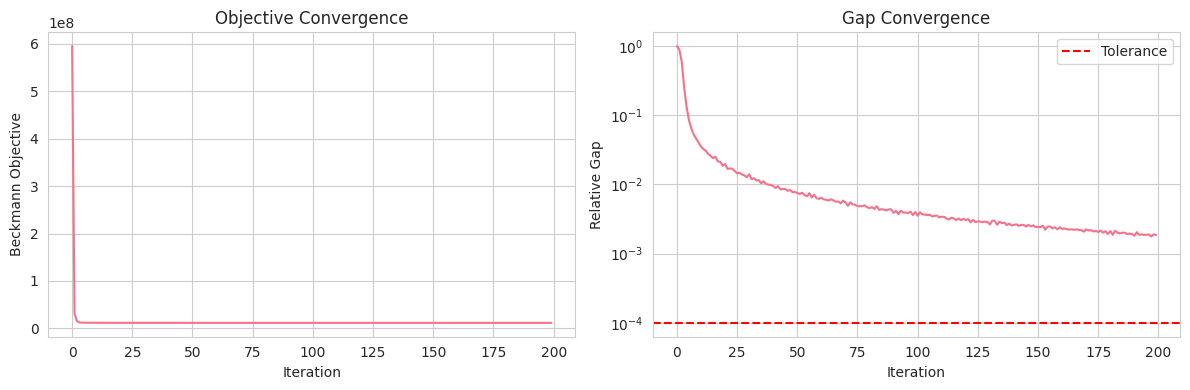

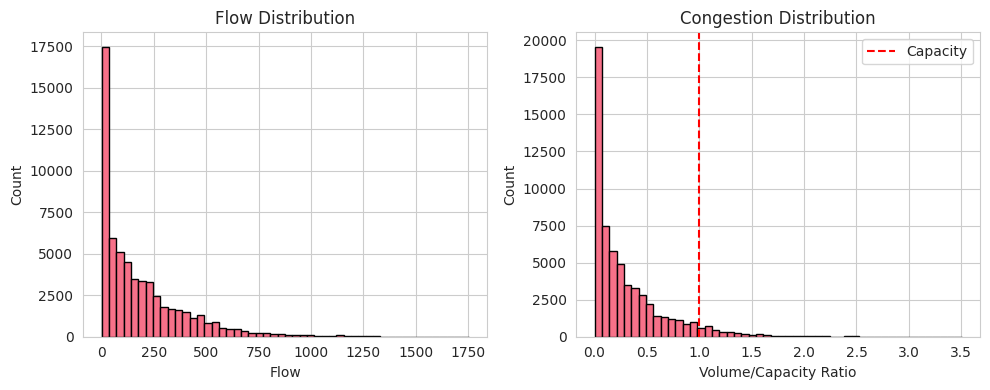

In [ ]:


# =============================================================================
# CELL 11: Visualization (Optional)
# =============================================================================

import matplotlib.pyplot as plt

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Objective value
axes[0].plot(result.objective_values)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Beckmann Objective')
axes[0].set_title('Objective Convergence')
axes[0].grid(True)

# Relative gap
axes[1].semilogy(result.gaps)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Relative Gap')
axes[1].set_title('Gap Convergence')
axes[1].axhline(y=1e-4, color='r', linestyle='--', label='Tolerance')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Flow distribution histogram
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(result.flow[result.flow > 0], bins=50, edgecolor='black')
plt.xlabel('Flow')
plt.ylabel('Count')
plt.title('Flow Distribution')

plt.subplot(1, 2, 2)
vcr = result.flow / net.capacity
plt.hist(vcr[vcr > 0], bins=50, edgecolor='black')
plt.axvline(x=1.0, color='r', linestyle='--', label='Capacity')
plt.xlabel('Volume/Capacity Ratio')
plt.ylabel('Count')
plt.title('Congestion Distribution')
plt.legend()

plt.tight_layout()
plt.show()